# Training run 3: figures

**Toward Personalized Hebrew ASR** · Dolev Abudi, Hadas Yonat

The figures for the third training run (plan v3, 2026-10-02). `docs/training_run3.md` has the write-up;
this notebook draws its tables and answers three questions about the winning recipe. `docs/STATUS.md` is where the
project stands now, and its § Withdrawn lists the claims not to rely on.

| | file | what |
|---|---|---|
| results | `src/training/outputs/results_v3.csv` | 144 rows: 72 adapters (12 speakers × budgets/seeds/targets), 72 control evaluations |
| tuning | `src/training/outputs/tuning_v3.csv`, `recipe_v3.json` | 64 validation-only tuning runs, and the recipe the rule chose |
| training curves | `runs/*/train_meta.json`, `runs_tune/*/train_meta.json` in the HF dataset `knesset-asr/knesset-committees-v3-results` | training loss every 5 steps, validation loss every 20 |

The git tables are checked against the HF copy (the run's backup of record) before anything is drawn.

**Conventions.**
- Relative change in WER, **positive = better**: `delta_rel = (WER_base − WER_tuned) / WER_base`.
- **Own** is the speaker's adapter. **Control** is an adapter trained on the same number of minutes from the
  other fold's speakers, never on a meeting the speaker is tested on.
- **Personalization = own − control** in relative points: `(WER_control − WER_own) / WER_base`.
- **Two test sets.** The *clean test* holds the speaker's clips at alignment quality ≥ 0.95. The *full test*
  holds every clip of the same meetings at quality ≥ 0.7 (columns `test07.*`).
- **Significance** is the paired bootstrap over test chunks (`p_boot`, `personalization_p`), with p < 0.05.

**What is withdrawn, and how this notebook handles it** (`docs/STATUS.md` § Withdrawn):
- **The forgiven-shared count (`*_f` columns).** It assumed that when two models agree against the protocol, the
  protocol is wrong. On human-corrected clips that held only about half the time
  (`docs/personalization_research.md` § 1.5). Its columns are dropped on load.
- **The semi-verbatim targets (`targets == 'verbatim'`, the run's "Extra").** They rest on the same assumption,
  so they put back about as many unspoken words as spoken ones. They are also scored against the protocol they
  deliberately depart from. Their 24 rows are listed below and then left out of every figure.

**Every WER here is measured against the protocol, not against what was said.** On human-corrected committee clips
the protocol differs from the speech by ~18 % of its words. The gains below are gains in agreement with the
protocol; whether the personal effect is larger against the speech is not known (`docs/STATUS.md`).

---
## 0. Load and check the data

In [1]:
import os, json, warnings
warnings.filterwarnings('ignore', message='IProgress not found')
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
from matplotlib.lines import Line2D
from huggingface_hub import HfApi, hf_hub_download, snapshot_download

# Okabe-Ito, colour-blind safe.  Roles are fixed across every figure.
C_OWN, C_CTRL, C_PERS, C_BASE = '#0072B2', '#D55E00', '#009E73', '#7F7F7F'
C_SET = ['#0072B2', '#E69F00', '#CC79A7']            # settings within one tuning panel, in order
SEED_MARK, SEED_LS = {0: 'o', 1: 's', 2: '^'}, {0: '-', 1: '--', 2: ':'}

OUT = os.path.join('..', 'src', 'training', 'outputs')
HF_REPO = 'knesset-asr/knesset-committees-v3-results'
HF_DIR = os.path.join(OUT, 'hf_v3')                   # src/training/outputs/ is gitignored
FIG = os.path.join('..', 'docs', 'figures', 'training_run3'); os.makedirs(FIG, exist_ok=True)
def save(name): plt.savefig(os.path.join(FIG, name + '.png'), dpi=130, bbox_inches='tight')
pd.set_option('display.width', 180); pd.set_option('display.max_columns', 40)

R = pd.read_csv(os.path.join(OUT, 'results_v3.csv'))
T = pd.read_csv(os.path.join(OUT, 'tuning_v3.csv'))
RECIPE = {int(b): v for b, v in json.load(open(os.path.join(OUT, 'recipe_v3.json')))['recipe'].items()}

# The latest results: git's tables must equal the run's own copy on HF.
last = HfApi().list_repo_commits(HF_REPO, repo_type='dataset')[0]
print(f'HF dataset last updated {last.created_at:%Y-%m-%d %H:%M} UTC ({last.title})')
for local, remote in [(R, 'results.csv'), (T, 'tuning.csv')]:
    hf = pd.read_csv(hf_hub_download(HF_REPO, remote, repo_type='dataset', local_dir=HF_DIR))
    pd.testing.assert_frame_equal(local, hf, check_exact=False)
    print(f'  {remote:<12} = git ({len(hf)} rows, {hf.shape[1]} columns)')

# Training curves: only the small train_meta.json files, not the adapters.
snapshot_download(HF_REPO, repo_type='dataset', local_dir=HF_DIR,
                  allow_patterns=['runs/*/train_meta.json', 'runs_tune/*/train_meta.json'])
def meta(kind, run): return json.load(open(os.path.join(HF_DIR, kind, run, 'train_meta.json'), encoding='utf-8'))

FORGIVEN = [c for c in R.columns if c.endswith('_f') or '_f.' in c]          # the withdrawn forgiven-shared count
R = R.drop(columns=FORGIVEN)
print(f'dropped {len(FORGIVEN)} forgiven-WER columns (withdrawn); {R.shape[1]} left')
ALL = R                                                                     # incl. the withdrawn semi-verbatim rows
R = R[R.targets == 'protocol'].copy()                                       # every figure below
own, ctrl = R[~R.control].copy(), R[R.control].copy()
SPK = sorted(R.speaker.unique())
# Speaker profiles from the panel design (docs/training_run3.md, per-speaker table).
PROFILE = {556: 'S2', 23558: 'S2', 30685: 'S1', 30701: 'S1', 30718: 'S3', 30752: 'C', 30777: 'C',
           30813: 'S3', 30831: 'S1', 30843: 'S2', 30859: 'S4', 30868: 'S3'}
TESTS = {'': 'clean test (quality ≥ 0.95)', 'test07.': 'full test (quality ≥ 0.7)'}
WIN = own[(own.targets == 'protocol') & (own.budget == 80)]            # the winning recipe, 3 seeds

print(f'\n{len(ALL)} rows; kept {len(R)} with protocol targets: {len(own)} adapters, {len(ctrl)} control evaluations, '
      f'{len(SPK)} speakers ({len(ALL) - len(R)} semi-verbatim rows left out)')
pd.crosstab([ALL.targets, ALL.budget], [ALL.control.map({False: 'own', True: 'control'}), ALL.seed])

HF dataset last updated 2026-10-02 15:59 UTC (backup targets_verbatim.parquet)


  results.csv  = git (144 rows, 227 columns)
  tuning.csv   = git (64 rows, 14 columns)


Fetching ... files: 0it [00:00, ?it/s]

Fetching ... files: 148it [00:00, 7393.84it/s]

dropped 78 forgiven-WER columns (withdrawn); 149 left

144 rows; kept 120 with protocol targets: 60 adapters, 60 control evaluations, 12 speakers (24 semi-verbatim rows left out)


control         control         own        
seed                  0   1   2   0   1   2
targets  budget                            
protocol 5           12   0   0  12   0   0
         20          12   0   0  12   0   0
         80          12  12  12  12  12  12
verbatim 80          12   0   0  12   0   0

---
## 1. Own vs control vs personalization, by budget

Seed 0, protocol targets. Each dot is one speaker; the bar and the number are the median over the 12.

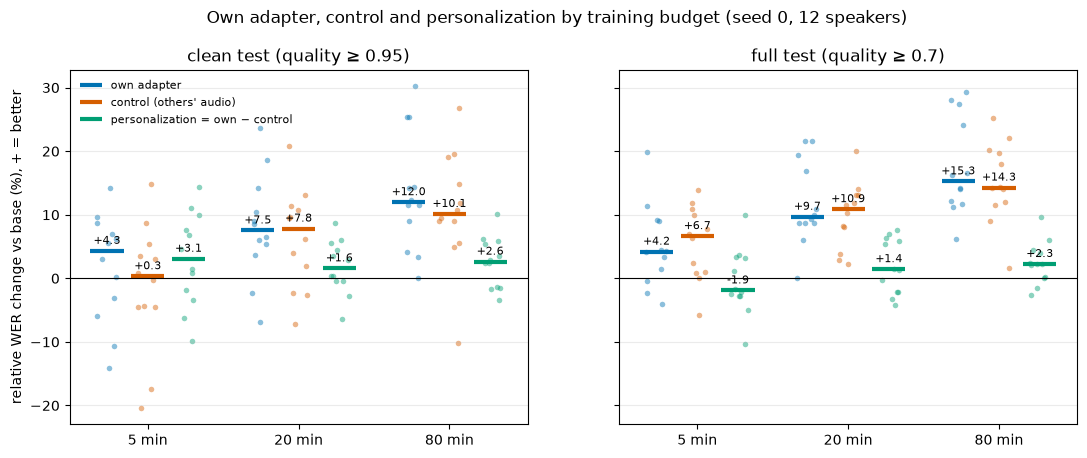

,budget,test,own %,control %,personalization %,own sig. better than base,personalization sig. +,personalization sig. −
0,5,clean test,4.3,0.3,3.1,6,4,1
1,5,full test,4.2,6.7,-1.9,7,2,3
2,20,clean test,7.5,7.8,1.6,8,3,0
3,20,full test,9.7,10.9,1.4,11,5,2
4,80,clean test,12.0,10.1,2.6,9,2,0
5,80,full test,15.3,14.3,2.3,12,5,0


In [2]:
s0 = own[(own.targets == 'protocol') & (own.seed == 0)]
ROLES = [('delta_rel', C_OWN, 'own adapter'), ('control_delta_rel', C_CTRL, "control (others' audio)"),
         ('personalization_rel', C_PERS, 'personalization = own − control')]
rng = np.random.default_rng(0)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6), sharey=True)
for ax, (pre, name) in zip(axes, TESTS.items()):
    for i, b in enumerate([5, 20, 80]):
        d = s0[s0.budget == b]
        for j, (col, c, lab) in enumerate(ROLES):
            x, v = i + (j - 1) * 0.27, 100 * d[pre + col]
            ax.scatter(x + rng.uniform(-.07, .07, len(v)), v, s=16, color=c, alpha=.45, lw=0)
            ax.hlines(v.median(), x - .11, x + .11, color=c, lw=3, label=lab if i == 0 else None)
            ax.annotate(f'{v.median():+.1f}', (x, v.median()), xytext=(0, 5), textcoords='offset points',
                        ha='center', fontsize=8)
    ax.axhline(0, color='k', lw=.8); ax.set_xticks(range(3), ['5 min', '20 min', '80 min'])
    ax.set_title(name); ax.grid(axis='y', alpha=.25)
axes[0].set_ylabel('relative WER change vs base (%), + = better')
axes[0].legend(loc='upper left', fontsize=8, frameon=False)
fig.suptitle('Own adapter, control and personalization by training budget (seed 0, 12 speakers)', y=1.01)
save('budget_own_control_personalization'); plt.show()

def sig_pos(d, p, eff): return int(((d[p] < .05) & (d[eff] > 0)).sum())
def sig_neg(d, p, eff): return int(((d[p] < .05) & (d[eff] < 0)).sum())
rows = []
for b in [5, 20, 80]:
    d = s0[s0.budget == b]
    for pre, name in TESTS.items():
        rows.append({'budget': b, 'test': name.split(' (')[0],
                     'own %': 100 * d[pre + 'delta_rel'].median(), 'control %': 100 * d[pre + 'control_delta_rel'].median(),
                     'personalization %': 100 * d[pre + 'personalization_rel'].median(),
                     'own sig. better than base': sig_pos(d, pre + 'p_boot', pre + 'delta_rel'),
                     'personalization sig. +': sig_pos(d, pre + 'personalization_p', pre + 'personalization_rel'),
                     'personalization sig. −': sig_neg(d, pre + 'personalization_p', pre + 'personalization_rel')})
pd.DataFrame(rows).round(1)

**Reading.**
- **The own adapter's gain grows with data**: +4 / +7.5 / +12 % on the clean test and +4 / +10 / +15 % on the
  full test, at 5 / 20 / 80 minutes.
- **The control grows almost as fast.** Most of the gain is committee Hebrew, which anyone's audio teaches.
- **So personalization stays flat at +1.5 to +3 points at every budget.**
- **The 5-minute column is noise.** The 5-minute control is nearly untrained, which is why the clean test and the
  full test give it opposite signs.
- **Significantly negative speakers.** At 80 minutes there are none. At 5 and 20 minutes there are 1–3 per test
  (30813, 30752 and 556 at 5 minutes; 30831 and 30843 at 20). `docs/training_run3.md` says "no speaker is
  significantly negative at any budget", which holds only at 80 minutes.

---
## 2. Per-speaker personalization across seeds, with 95% CIs

80 minutes, protocol targets, seeds 0–2. The CI is the paired bootstrap of own against control on the same
chunks (`personalization_ci_lo/hi`, absolute WER), divided by the base WER to put it in the same relative
units as the point. Filled marker = p < 0.05. Speakers are sorted by their mean over seeds on the full test.

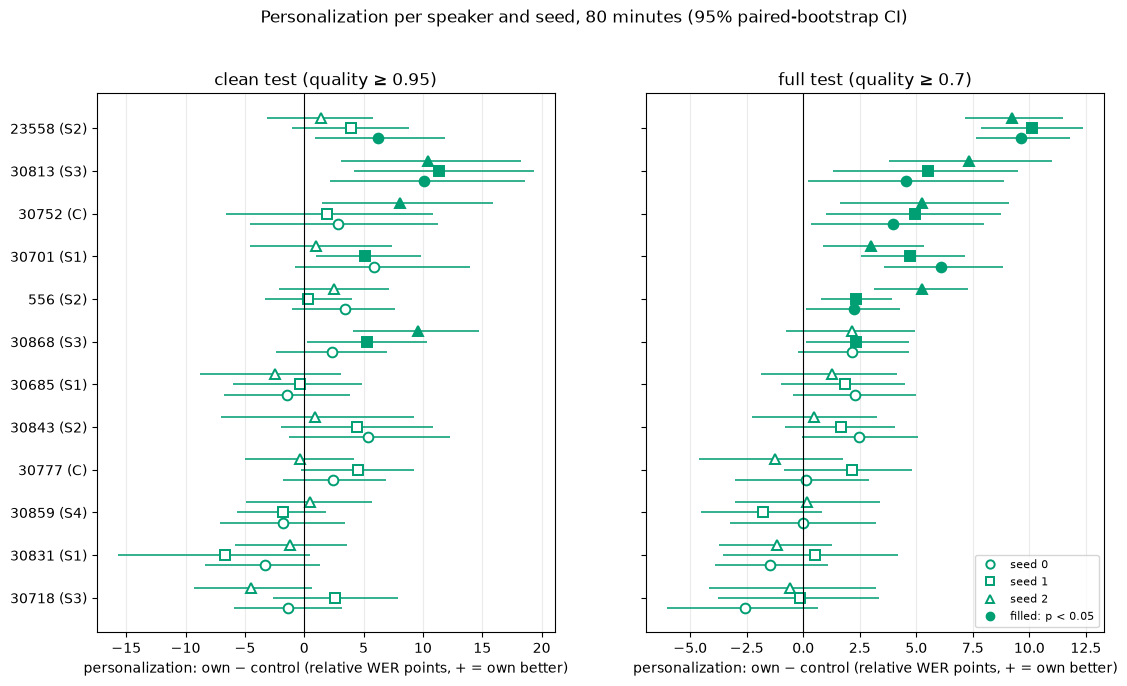

personalization_rel             test07.personalization_rel            seeds sig. + (clean) seeds sig. + (full)
seed                      0     1     2                          0     1    2                                         
speaker                                                                                                               
23558                   6.2   3.9   1.4                        9.6  10.1  9.2                    1                   3
30813                  10.1  11.4  10.4                        4.5   5.5  7.3                    3                   3
30752                   2.8   2.0   8.0                        4.0   5.0  5.2                    1                   3
30701                   5.8   5.1   1.0                        6.1   4.7  3.0                    1                   3
556                     3.4   0.3   2.5                        2.2   2.3  5.2                    0                   3
30868                   2.3   5.3   9.6                        2.1   2.4  2.2                    2                   1
30685                  -1.5  -0.4  -2.5                        2.3   1.9  1.3                    0                   0
30843                   5.4   4.5   0.9                        2.5   1.7  0.5                    0                   0
30777                   2.4   4.5  -0.4                        0.1   2.1 -1.3                    0                   0
30859                  -1.8  -1.8   0.5                        0.0  -1.8  0.2                    0                   0
30831                  -3.3  -6.7  -1.2                       -1.5   0.5 -1.2                    0                   0
30718                  -1.4   2.6  -4.4                       -2.6  -0.2 -0.6                    0                   0

In [3]:
order = WIN.groupby('speaker')['test07.personalization_rel'].mean().sort_values().index
fig, axes = plt.subplots(1, 2, figsize=(13, 7), sharey=True)
for ax, (pre, name) in zip(axes, TESTS.items()):
    for y, spk in enumerate(order):
        for s in [0, 1, 2]:
            r = WIN[(WIN.speaker == spk) & (WIN.seed == s)].iloc[0]
            yy, base = y + (s - 1) * .24, r[pre + 'wer_base']
            lo, hi = 100 * r[pre + 'personalization_ci_lo'] / base, 100 * r[pre + 'personalization_ci_hi'] / base
            v, sig = 100 * r[pre + 'personalization_rel'], r[pre + 'personalization_p'] < .05
            ax.hlines(yy, lo, hi, color=C_PERS, lw=1.4, alpha=.8)
            ax.plot(v, yy, SEED_MARK[s], ms=7, color=C_PERS, mfc=C_PERS if sig else 'white', mew=1.4)
    ax.axvline(0, color='k', lw=.8); ax.grid(axis='x', alpha=.25)
    ax.set_title(name); ax.set_xlabel('personalization: own − control (relative WER points, + = own better)')
axes[0].set_yticks(range(len(order)), [f'{s} ({PROFILE[s]})' for s in order])
handles = [Line2D([], [], marker=SEED_MARK[s], ls='', color=C_PERS, mfc='white', mew=1.4, label=f'seed {s}') for s in [0, 1, 2]]
handles += [Line2D([], [], marker='o', ls='', color=C_PERS, label='filled: p < 0.05')]
axes[1].legend(handles=handles, loc='lower right', fontsize=8)
fig.suptitle('Personalization per speaker and seed, 80 minutes (95% paired-bootstrap CI)', y=1.0)
save('personalization_per_speaker_seeds'); plt.show()

t = WIN.pivot_table(index='speaker', columns='seed', values=['personalization_rel', 'test07.personalization_rel'])
t = (100 * t).round(1)
t['seeds sig. + (clean)'] = WIN.groupby('speaker')[list(WIN.columns.drop('speaker'))].apply(lambda d: sig_pos(d, 'personalization_p', 'personalization_rel'))
t['seeds sig. + (full)'] = WIN.groupby('speaker')[list(WIN.columns.drop('speaker'))].apply(lambda d: sig_pos(d, 'test07.personalization_p', 'test07.personalization_rel'))
t.loc[order[::-1]]

**Reading.**
- **Five speakers are significant in all three seeds on the full test:** 23558, 30813, 30752, 30701 and 556.
  - 23558 is the largest and the most stable: +9 to +10 points in every seed.
  - 30813's clean-test effect is partly the control *hurting* her (the control is −8 % against base, §6a), not
    only her own adapter helping.
- **Six speakers are never significant, in any seed or test:** 30685, 30843, 30777, 30859, 30831 and 30718. For
  them, "more committee Hebrew" is as good as "their own 80 minutes".
- **The clean test is noisier.** It is about half the size of the full test (45 against about 92 minutes a
  speaker), so its CIs are wider and fewer seeds reach significance.

---
## 3. By alignment-quality band of the full test

80 minutes, protocol targets, all seeds (36 speaker-seeds). The full test is split by each clip's alignment
quality. On the left is the base model's WER per band; on the right is what the adapters change. Lines are
medians; the shading is the interquartile range. Under each band is its median length per speaker.

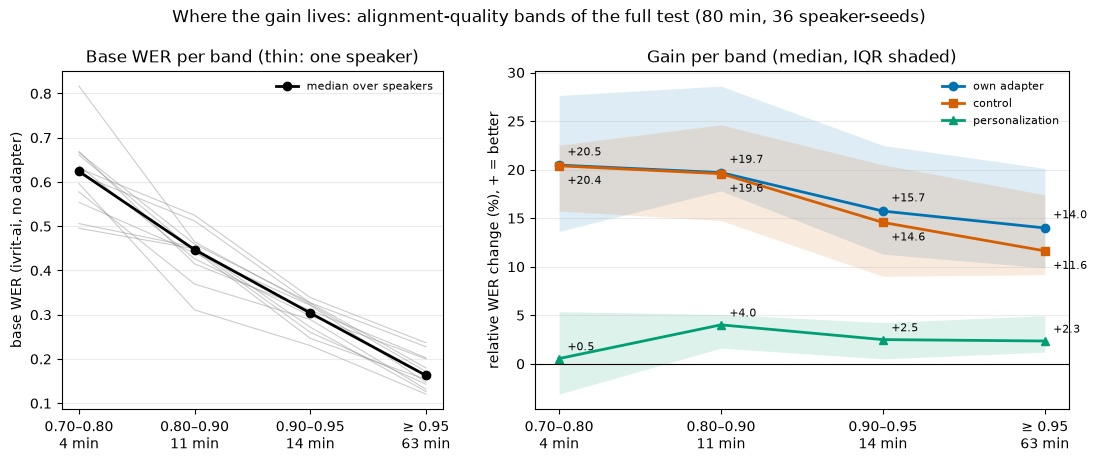

,band,minutes / speaker,base WER,own %,control %,personalization %
0,0.70–0.80,3.793,0.624,20.469,20.394,0.543
1,0.80–0.90,10.910,0.447,19.697,19.584,4.014
2,0.90–0.95,13.957,0.304,15.731,14.561,2.494
3,≥ 0.95,63.265,0.163,13.994,11.633,2.350


In [4]:
BANDS = [('q070', '0.70–0.80'), ('q080', '0.80–0.90'), ('q090', '0.90–0.95'), ('q095', '≥ 0.95')]
def band(q, what):
    p, d = f'test07.bands.{q}.', WIN
    if what == 'control': return d[p + 'control_delta_abs'] / d[p + 'wer_base']
    return d[p + {'base': 'wer_base', 'own': 'delta_rel', 'pers': 'personalization_rel'}[what]]
mins = [WIN[WIN.seed == 0][f'test07.bands.{q}.minutes'].median() for q, _ in BANDS]
xl = [f'{lab}\n{m:.0f} min' for (_, lab), m in zip(BANDS, mins)]
x = np.arange(len(BANDS))

fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4.4), gridspec_kw={'width_ratios': [1, 1.4]})
for spk in SPK:
    d = WIN[(WIN.speaker == spk) & (WIN.seed == 0)]
    a1.plot(x, [d[f'test07.bands.{q}.wer_base'].iloc[0] for q, _ in BANDS], color=C_BASE, lw=.8, alpha=.4)
a1.plot(x, [band(q, 'base').median() for q, _ in BANDS], 'o-', color='k', lw=2, label='median over speakers')
a1.set_xticks(x, xl); a1.set_ylabel('base WER (ivrit-ai, no adapter)'); a1.set_title('Base WER per band (thin: one speaker)')
a1.legend(fontsize=8, frameon=False); a1.grid(axis='y', alpha=.25)
for what, c, lab, m in [('own', C_OWN, 'own adapter', 'o'), ('control', C_CTRL, 'control', 's'), ('pers', C_PERS, 'personalization', '^')]:
    v = np.array([100 * band(q, what).quantile([.25, .5, .75]).values for q, _ in BANDS])
    a2.fill_between(x, v[:, 0], v[:, 2], color=c, alpha=.13, lw=0)
    a2.plot(x, v[:, 1], marker=m, color=c, lw=2, label=lab)
    dy = {'own': 7, 'control': -13, 'pers': 6}[what]          # own above, control below: they nearly coincide
    for xi, yi in zip(x, v[:, 1]): a2.annotate(f'{yi:+.1f}', (xi, yi), xytext=(6, dy), textcoords='offset points', fontsize=8)
a2.axhline(0, color='k', lw=.8); a2.set_xticks(x, xl); a2.grid(axis='y', alpha=.25)
a2.set_ylabel('relative WER change (%), + = better'); a2.set_title('Gain per band (median, IQR shaded)')
a2.legend(fontsize=8, frameon=False)
fig.suptitle('Where the gain lives: alignment-quality bands of the full test (80 min, 36 speaker-seeds)', y=1.02)
save('quality_bands'); plt.show()

pd.DataFrame({'band': [l for _, l in BANDS], 'minutes / speaker': mins,
              'base WER': [band(q, 'base').median() for q, _ in BANDS],
              'own %': [100 * band(q, 'own').median() for q, _ in BANDS],
              'control %': [100 * band(q, 'control').median() for q, _ in BANDS],
              'personalization %': [100 * band(q, 'pers').median() for q, _ in BANDS]}).round(3)

**Reading.**
- **Base WER falls steeply with alignment quality**, from 0.62 to 0.16: low-quality clips are the ones whose
  protocol text matches the audio worst.
- **The adapters gain most on the hard bands**: about +20 % at 0.7–0.9 against +14 % on the clean band. But the
  control gains just as much there, so this is the domain, not the speaker.
- **Personalization is about 0 on the worst band and +2 to +4 points elsewhere.** It does not grow on the
  cleanest clips.
- **Most of the full test is clean audio.** The ≥ 0.95 band is 63 of the ~92 minutes a speaker; the worst band
  is only 4.

---
## 4. Tuning

Validation only: 4 speakers (one per profile), at 5 and 80 minutes. The criterion is `rel_drop`, the relative
drop in validation loss from the untuned model to the best checkpoint. The rule (`v3_decide.py`): a setting
replaces the simpler incumbent only if it raises the mean by ≥ 0.01 **and** helps ≥ 3 of the 4 speakers.

### 4a. Every tuning run's score

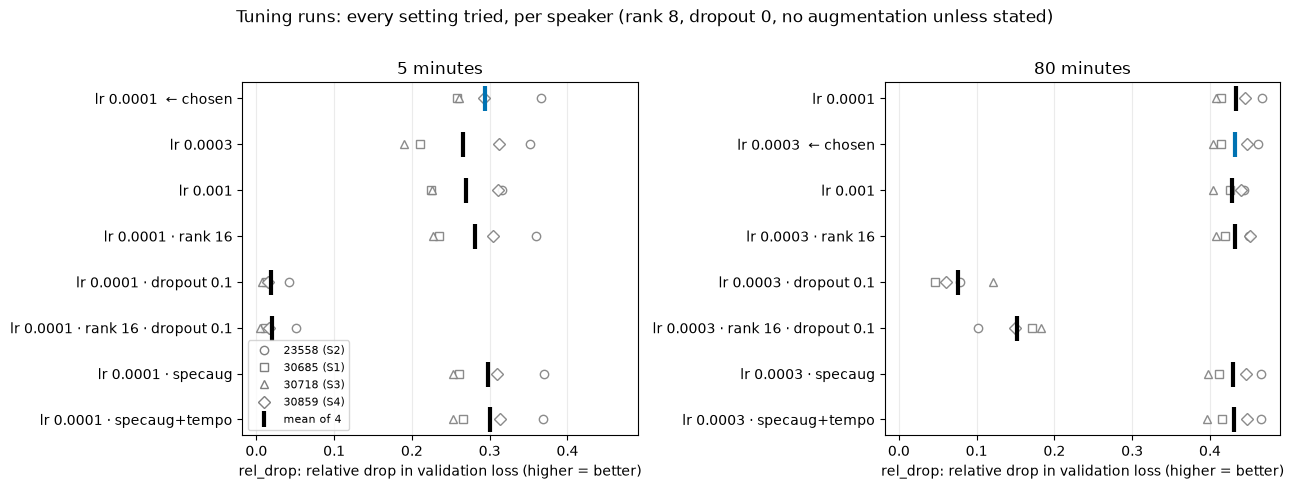

budget,5,80
setting,,
lr 0.0001,0.294,0.434
lr 0.0001 · dropout 0.1,0.019,NaN
lr 0.0001 · rank 16,0.281,NaN
lr 0.0001 · rank 16 · dropout 0.1,0.021,NaN
lr 0.0001 · specaug,0.298,NaN
lr 0.0001 · specaug+tempo,0.300,NaN
lr 0.0003,0.266,0.432
lr 0.0003 · dropout 0.1,NaN,0.077
lr 0.0003 · rank 16,NaN,0.432


In [5]:
def setting(r):
    s = f"lr {r.lr:g}"
    if r['rank'] != 8: s += ' · rank 16'
    if r.dropout: s += f' · dropout {r.dropout:g}'
    if r.augment != 'none': s += ' · ' + r.augment
    return s
T['setting'] = T.apply(setting, axis=1)
T['chosen'] = T.apply(lambda r: all(r[k] == RECIPE[r.budget][k] for k in ('lr', 'rank', 'dropout', 'augment')), axis=1)
SPK_T = sorted(T.speaker.unique()); SPK_MARK = dict(zip(SPK_T, ['o', 's', '^', 'D']))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), sharex=True)
for ax, b in zip(axes, [5, 80]):
    d = T[T.budget == b]
    key = lambda s: (('specaug' in s), ('dropout' in s), ('rank' in s), s)
    sets = sorted(d.setting.unique(), key=key, reverse=True)
    for y, s in enumerate(sets):
        e = d[d.setting == s]
        for _, r in e.iterrows():
            ax.plot(r.rel_drop, y, SPK_MARK[r.speaker], color=C_BASE, ms=6, mfc='white', alpha=.9)
        ax.plot(e.rel_drop.mean(), y, '|', color=C_OWN if e.chosen.any() else 'k', ms=18, mew=3)
    ax.set_yticks(range(len(sets)), [s + ('  ← chosen' if d[d.setting == s].chosen.any() else '') for s in sets])
    ax.set_title(f'{b} minutes'); ax.grid(axis='x', alpha=.25); ax.set_xlabel('rel_drop: relative drop in validation loss (higher = better)')
handles = [Line2D([], [], marker=SPK_MARK[s], ls='', color=C_BASE, mfc='white', label=f'{s} ({PROFILE[s]})') for s in SPK_T]
handles += [Line2D([], [], marker='|', ls='', color='k', ms=12, mew=3, label='mean of 4')]
axes[0].legend(handles=handles, fontsize=8, loc='lower left')
fig.suptitle('Tuning runs: every setting tried, per speaker (rank 8, dropout 0, no augmentation unless stated)', y=1.01)
plt.tight_layout(); save('tuning_scores'); plt.show()
T.pivot_table(index='setting', columns='budget', values='rel_drop', aggfunc='mean').round(3)

**Reading.** Every setting except Whisper dropout lands within about 3 points of the others.
- **Rank 16 = rank 8 at 80 minutes (0.432 vs 0.432)** and is worse at 5. Rank 8 was kept by the rule.
  Rank 16 never reached the test sets.
- **The learning rate matters only at 5 minutes**, where 1e-4 wins on 3 of 4 speakers.
- **Augmentation helps by less than the 0.01 threshold.**
- **Whisper dropout 0.1 is destructive**: the validation drop collapses to 2–15 %.

### 4b. Tuning curves: validation loss during training

Validation loss divided by the untuned model's (step 0 = 1.0), every 20 steps. Each panel varies one setting
around the chosen recipe. The thin lines are the 4 speakers, and the thick line is their mean while all 4 are
still training. The dot marks the best checkpoint, which is what early stopping restored.

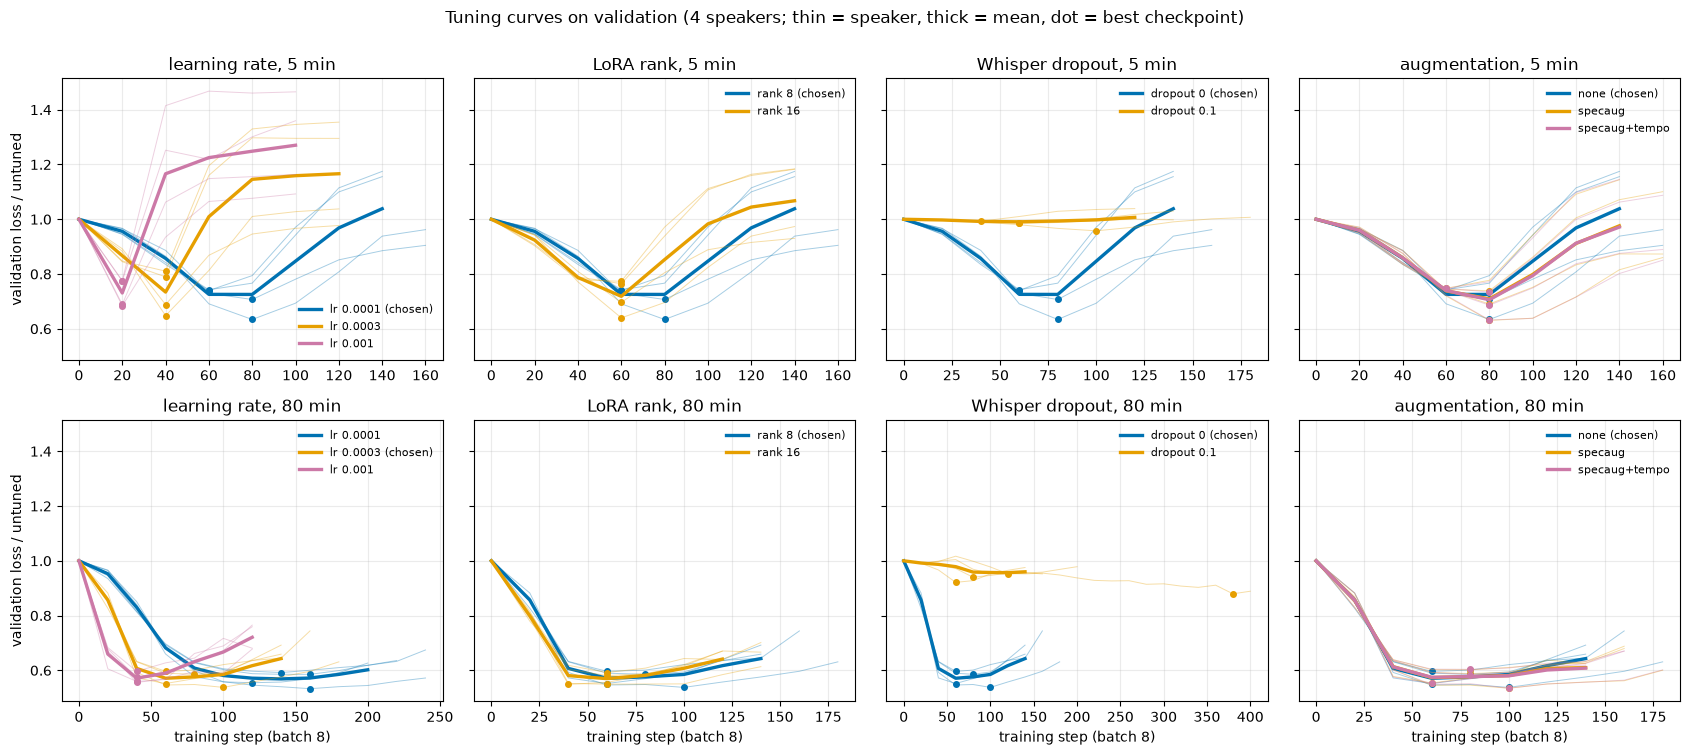

In [6]:
def curve(m):
    ev = [(0, m['base_eval_loss'])] + [(e['step'], e['eval_loss']) for e in m['evals'] if 'eval_loss' in e]
    s = pd.Series(dict(ev)).sort_index()
    return s / m['base_eval_loss']
def comparisons(b):
    lr = RECIPE[b]['lr']
    base = (T.budget == b) & (T['rank'] == 8) & (T.dropout == 0) & (T.augment == 'none')
    return {'learning rate': (T[base], 'lr', lambda v: f'lr {v:g}'),
            'LoRA rank': (T[(T.budget == b) & (T.lr == lr) & (T.dropout == 0) & (T.augment == 'none')], 'rank', lambda v: f'rank {v}'),
            'Whisper dropout': (T[(T.budget == b) & (T.lr == lr) & (T['rank'] == 8) & (T.augment == 'none')], 'dropout', lambda v: f'dropout {v:g}'),
            'augmentation': (T[(T.budget == b) & (T.lr == lr) & (T['rank'] == 8) & (T.dropout == 0)], 'augment', str)}

fig, axes = plt.subplots(2, 4, figsize=(17, 7.5), sharey=True)
for row, b in zip(axes, [5, 80]):
    for ax, (title, (d, col, fmt)) in zip(row, comparisons(b).items()):
        for k, (v, e) in enumerate(d.groupby(col)):
            c = C_SET[k]; curves = [curve(meta('runs_tune', r)) for r in e.run]
            for cv in curves: ax.plot(cv.index, cv.values, color=c, lw=.7, alpha=.35)
            common = pd.concat(curves, axis=1).dropna()
            chosen = RECIPE[b][col] == v
            ax.plot(common.index, common.mean(1), color=c, lw=2.4, label=fmt(v) + (' (chosen)' if chosen else ''))
            for r in e.itertuples():
                cv = curve(meta('runs_tune', r.run)); ax.plot(r.best_step, cv.get(r.best_step, np.nan), 'o', color=c, ms=4)
        ax.set_title(f'{title}, {b} min'); ax.grid(alpha=.25); ax.legend(fontsize=8, frameon=False)
        if ax is row[0]: ax.set_ylabel('validation loss / untuned')
        if b == 80: ax.set_xlabel('training step (batch 8)')
fig.suptitle('Tuning curves on validation (4 speakers; thin = speaker, thick = mean, dot = best checkpoint)', y=1.0)
plt.tight_layout(); save('tuning_curves'); plt.show()

**Reading.**
- **The validation loss bottoms out early and then rises (overfitting).** That is why early stopping matters
  more than any tuned setting.
- **Early stopping is what makes the rate irrelevant at 80 minutes.** All three rates reach the same minimum,
  just at different steps (later for 1e-4, earlier for 1e-3).
- **At 5 minutes, the higher rates overshoot.** 3e-4 and 1e-3 end above the untuned model's loss within 60 steps,
  so only the restored best checkpoint is usable.
- **Dropout 0.1 hardly moves the validation loss at all.**

---
## 5. WER against the amount of training data

Absolute WER per speaker at 0 (the base model), 5, 20 and 80 minutes, for the own adapter and the control.
At 5 and 20 minutes there is only seed 0; at 80 minutes the line goes through the mean of the three seeds,
and the small marks are the individual seeds. The median panel comes first; one panel per speaker follows.

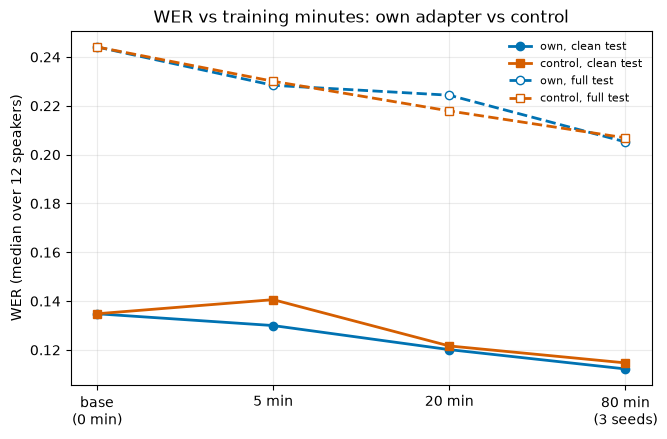

,"own, clean test","control, clean test","own, full test","control, full test"
base,0.135,0.135,0.244,0.244
5 min,0.130,0.141,0.228,0.230
20 min,0.120,0.122,0.224,0.218
80 min,0.112,0.115,0.205,0.207


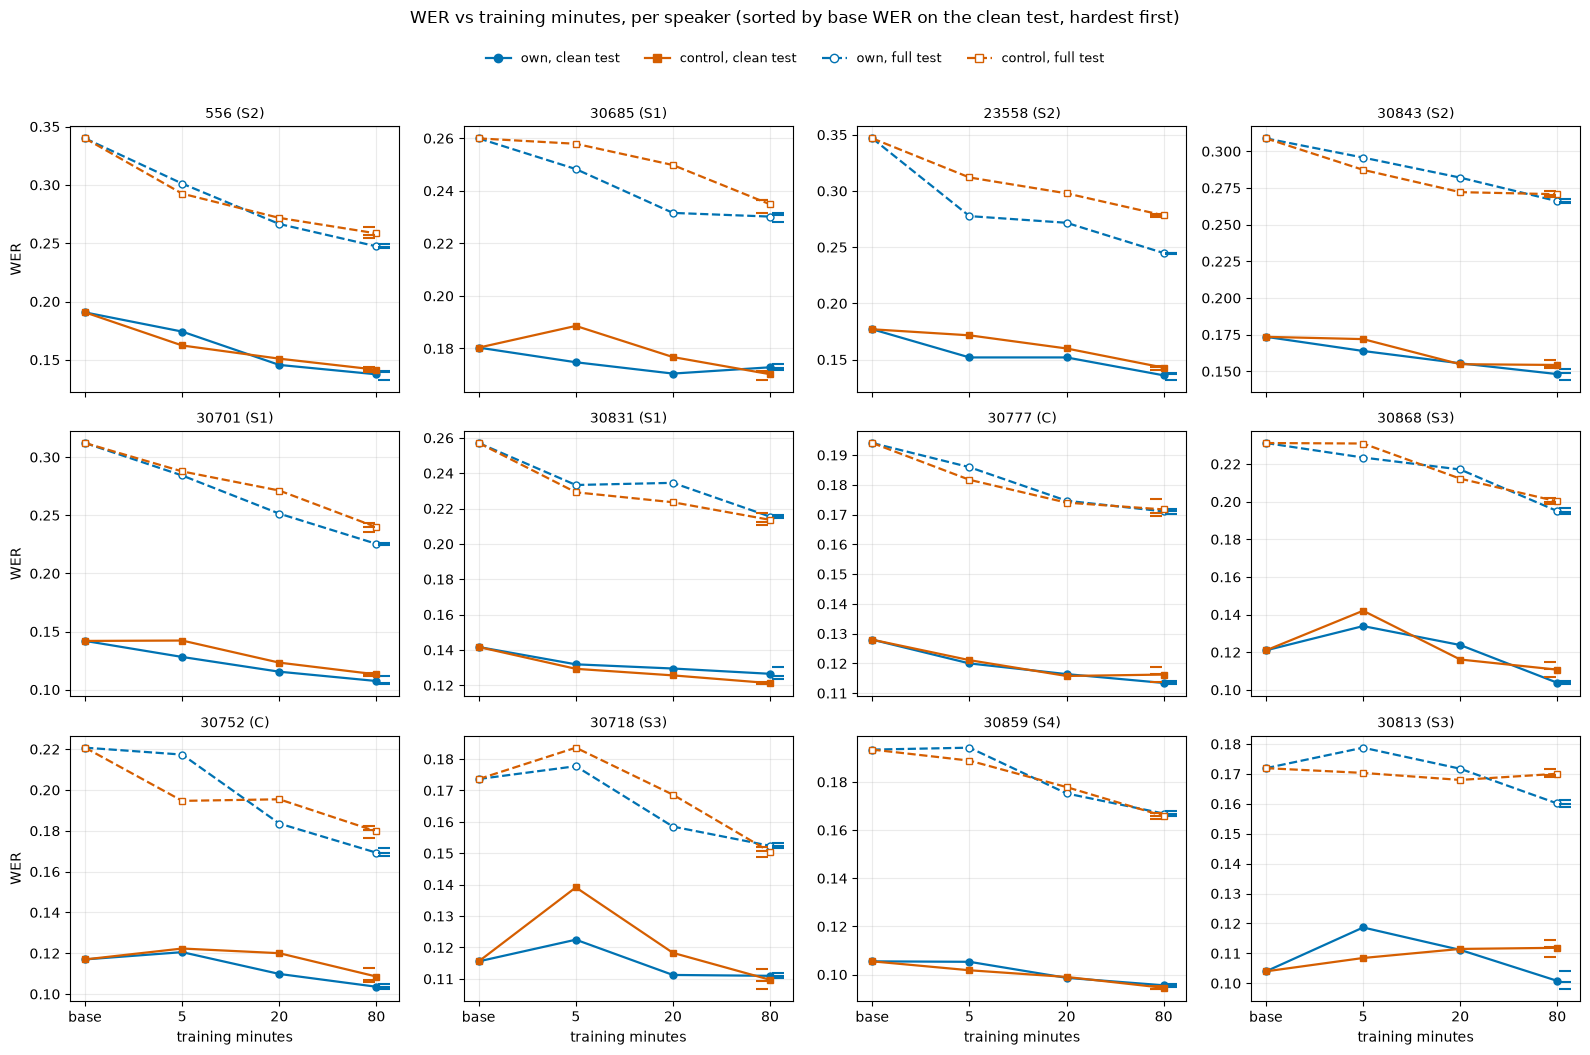

In [7]:
BUD, XP = [0, 5, 20, 80], np.arange(4)
def wer_of(d, pre, who):         # the control's WER = base - its gain (no test07.wer_control column)
    return d[pre + 'wer_tuned'] if who == 'own' else d[pre + 'wer_base'] - d[pre + 'control_delta_abs']
def wer_line(d, pre, spk, who):
    p = d[(d.speaker == spk) & (d.targets == 'protocol')]
    w = wer_of(p, pre, who)
    return [p[pre + 'wer_base'].iloc[0]] + [w[(p.budget == b) & (p.seed == 0)].iloc[0] for b in (5, 20)] + [w[p.budget == 80].mean()]
STY = {('own', ''): dict(color=C_OWN, marker='o', ls='-'), ('control', ''): dict(color=C_CTRL, marker='s', ls='-'),
       ('own', 'test07.'): dict(color=C_OWN, marker='o', ls='--', mfc='white'), ('control', 'test07.'): dict(color=C_CTRL, marker='s', ls='--', mfc='white')}

fig, ax = plt.subplots(figsize=(7.5, 4.6))
for (who, pre), st in STY.items():
    L = np.array([wer_line(own, pre, s, who) for s in SPK])
    ax.plot(XP, np.median(L, 0), lw=2, ms=6, label=f'{who}, {TESTS[pre].split(" (")[0]}', **st)
ax.set_xticks(XP, ['base\n(0 min)', '5 min', '20 min', '80 min\n(3 seeds)']); ax.set_ylabel('WER (median over 12 speakers)')
ax.grid(alpha=.25); ax.legend(fontsize=8, frameon=False); ax.set_title('WER vs training minutes: own adapter vs control')
save('wer_vs_minutes_median'); plt.show()
display(pd.DataFrame({f'{w}, {TESTS[p].split(" (")[0]}': np.median([wer_line(own, p, s, w) for s in SPK], 0) for (w, p) in STY},
                     index=['base', '5 min', '20 min', '80 min']).round(3))

fig, axes = plt.subplots(3, 4, figsize=(16, 10), sharex=True)
for ax, spk in zip(axes.flat, sorted(SPK, key=lambda s: -own[own.speaker == s].wer_base.iloc[0])):
    for (who, pre), st in STY.items():
        ax.plot(XP, wer_line(own, pre, spk, who), lw=1.6, ms=5, **st)
        e = wer_of(WIN[WIN.speaker == spk], pre, who)
        ax.plot(np.full(len(e), 3) + (.08 if who == 'own' else -.08), e, '_', color=st['color'], ms=8, mew=1.5)
    ax.set_title(f'{spk} ({PROFILE[spk]})', fontsize=10); ax.grid(alpha=.25); ax.set_xticks(XP, ['base', '5', '20', '80'])
for ax in axes[:, 0]: ax.set_ylabel('WER')
for ax in axes[-1]: ax.set_xlabel('training minutes')
handles = [Line2D([], [], lw=1.6, **st, label=f'{w}, {TESTS[p].split(" (")[0]}') for (w, p), st in STY.items()]
fig.legend(handles=handles, loc='upper center', ncol=4, fontsize=9, frameon=False, bbox_to_anchor=(.5, 1.02))
fig.suptitle('WER vs training minutes, per speaker (sorted by base WER on the clean test, hardest first)', y=1.05)
plt.tight_layout(); save('wer_vs_minutes_per_speaker'); plt.show()

**Reading.**
- **The data curve is shallow.** Median clean-test WER goes 0.135 → 0.130 → 0.120 → 0.112 for the own adapter
  and 0.135 → 0.141 → 0.122 → 0.115 for the control.
- **The own and control medians stay within 0.01 of each other at every budget**, except at 5 minutes on the
  clean test, where the control is nearly untrained.
- **Per speaker:**
  - The hard S2/S1 speakers (556, 23558, 30701) gain most, and their own line ends clearly under the control
    line on the full test.
  - For 30831 the control is at or below the own line at every budget, on both tests.
  - 30813 is the only speaker whose 80-minute control is worse than base on the clean test.

---
## 6. The winning model

The recipe the run settles on is the **own adapter at 80 minutes with protocol targets** (LoRA r = 8, lr 3e-4,
early stopping on validation loss), trained with three seeds.

### 6a. Is one model best for all, or most, speakers?

Every protocol-target model the run produced (own and control, at 5, 20 and 80 minutes), scored per speaker as
relative WER change against the base. The black box marks each row's best model.
- **Averaging.** The 80-minute models are averaged over their three seeds; the 5- and 20-minute models are one
  seed.
- **Not a model selection.** The winner is picked on the test set, so this describes the results; it does not
  choose a model.
- **The semi-verbatim adapters are left out** (withdrawn, see the top).

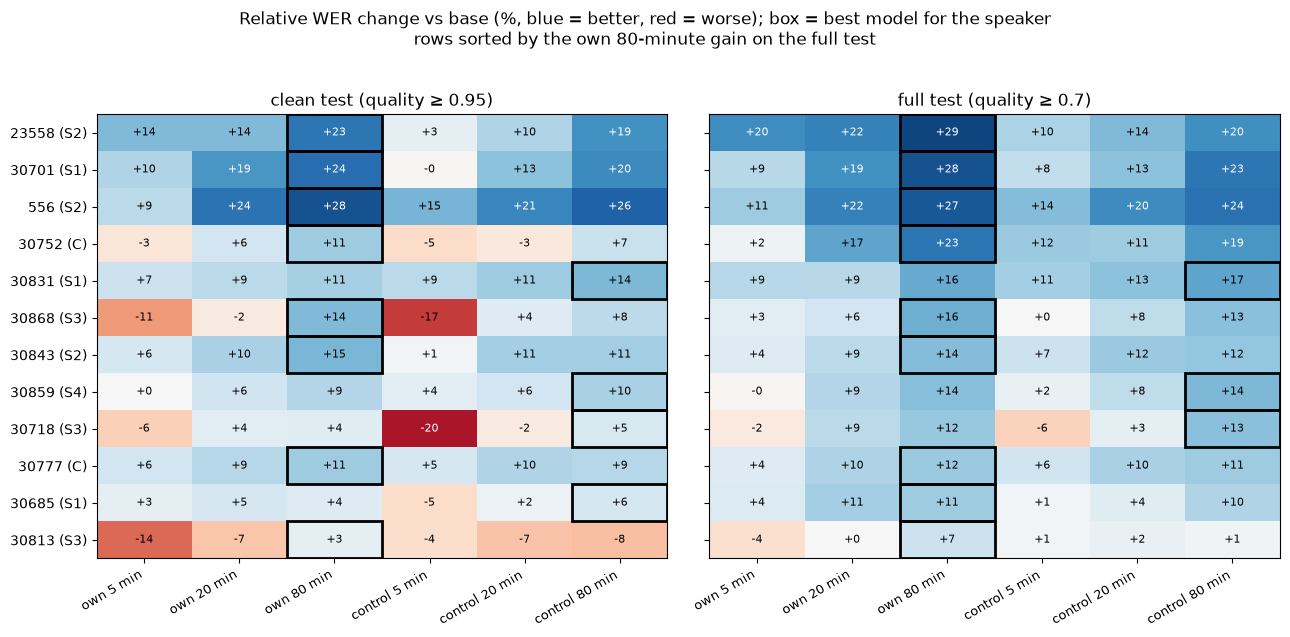

,clean test (quality ≥ 0.95),full test (quality ≥ 0.7)
own 80 min,8,9
control 80 min,4,3


,clean test (quality ≥ 0.95),full test (quality ≥ 0.7)
speaker: points behind the best,,
30685,1.5,NaN
30718,1.1,1.1
30831,3.7,0.7
30859,1.0,0.5


In [8]:
R['model'] = [f"{'control' if c else 'own'} {b} min" for c, b in zip(R.control, R.budget)]
COLS = ['own 5 min', 'own 20 min', 'own 80 min', 'control 5 min', 'control 20 min', 'control 80 min']
def gains(pre):
    W = R.groupby(['speaker', 'model'])[pre + 'wer_tuned'].mean().unstack()[COLS]
    return 100 * (1 - W.div(R.groupby('speaker')[pre + 'wer_base'].first(), axis=0))
ROWS = gains('test07.')['own 80 min'].sort_values(ascending=False).index    # one row order for both panels
fig, axes = plt.subplots(1, 2, figsize=(13, 6.2), sharey=True)
winners = {}
for ax, (pre, name) in zip(axes, TESTS.items()):
    G = gains(pre).loc[ROWS]
    winners[name] = G.idxmax(axis=1)
    ax.imshow(G.values, cmap='RdBu', norm=TwoSlopeNorm(0, -25, 32), aspect='auto')
    for i in range(G.shape[0]):
        for j in range(G.shape[1]):
            ax.text(j, i, f'{G.iat[i, j]:+.0f}', ha='center', va='center', fontsize=8,
                    color='white' if abs(G.iat[i, j]) > 18 else 'k')
        j = G.columns.get_loc(G.iloc[i].idxmax())
        ax.add_patch(plt.Rectangle((j - .5, i - .5), 1, 1, fill=False, ec='k', lw=2))
    ax.set_xticks(range(len(COLS)), COLS, rotation=30, ha='right', fontsize=9)
    ax.set_yticks(range(len(G)), [f'{s} ({PROFILE[s]})' for s in G.index]); ax.set_title(name)
fig.suptitle('Relative WER change vs base (%, blue = better, red = worse); box = best model for the speaker\n'
             'rows sorted by the own 80-minute gain on the full test', y=1.02)
plt.tight_layout(); save('best_model_per_speaker'); plt.show()
display(pd.DataFrame({k: v.value_counts() for k, v in winners.items()}).fillna(0).astype(int))
# where the own 80-minute adapter is not the best: by how much it trails
pd.DataFrame({name: (gains(pre).max(axis=1) - gains(pre)['own 80 min'])[winners[name] != 'own 80 min']
              for pre, name in TESTS.items()}).round(1).rename_axis('speaker: points behind the best')

**Answer: yes, for most speakers.**
- **The own adapter at 80 minutes is the best model for 8 of 12 speakers on the clean test and 9 of 12 on the
  full test.** On the full test it is 1st or 2nd for every speaker; on the clean test, never worse than 3rd of 6.
- **Where it loses, it loses to the 80-minute control.**
  - Clean test: 30685, 30718, 30831 and 30859.
  - Full test: 30718, 30831 and 30859.
  - The margin is 0.5–1.5 points, except 30831 on the clean test (3.7).
  - These are speakers with no personal effect in §2: for them, other people's committee audio does as well.
- **The short budgets lose.** Nothing at 5 or 20 minutes wins for anyone.
- **The 5-minute models can be worse than base**, down to −20 % for the 5-minute control on 30718.
- **30813 gains little from any model.** The own 80-minute adapter is her best (+3 % clean, +7 % full), while
  every other model is worse than base on the clean test.

### 6b. How many speakers improved?

Two separate questions: did the winning adapter beat the **base model**, and did it beat the **control**
(personalization)? Each one is counted over 36 speaker-seeds (12 speakers × 3 seeds), significance by paired
bootstrap at p < 0.05.

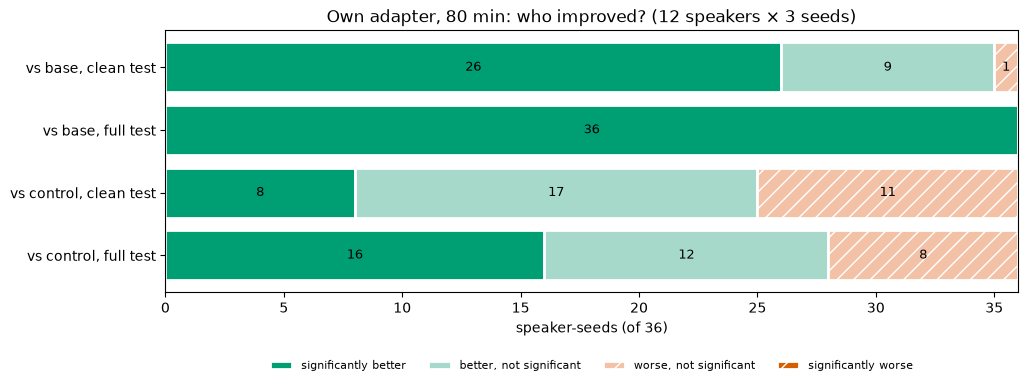

,significantly better,"better, not significant","worse, not significant",significantly worse
"vs base, clean test",26,9,1,0
"vs base, full test",36,0,0,0
"vs control, clean test",8,17,11,0
"vs control, full test",16,12,8,0


,"gain vs base, clean %","seeds sig. vs base, clean","gain vs base, full %","seeds sig. vs base, full","personalization, clean %","seeds sig. +, clean","personalization, full %","seeds sig. +, full"
23558 (S2),23.1,3,29.4,3,3.9,1,9.7,3
30813 (S3),3.1,0,6.9,3,10.6,3,5.8,3
30752 (C),11.4,3,23.3,3,4.3,1,4.7,3
30701 (S1),24.3,3,27.8,3,4.0,1,4.6,3
556 (S2),27.9,3,27.2,3,2.1,0,3.3,3
30868 (S3),14.2,3,15.6,3,5.8,2,2.2,1
30685 (S1),4.2,0,11.4,3,-1.5,0,1.8,0
30843 (S2),14.6,3,13.9,3,3.6,0,1.5,0
30777 (C),11.4,3,11.8,3,2.2,0,0.3,0
30859 (S4),9.4,3,13.7,3,-1.0,0,-0.5,0


In [9]:
def tally(d, p, eff):
    return {'significantly better': int(((d[p] < .05) & (d[eff] > 0)).sum()),
            'better, not significant': int(((d[p] >= .05) & (d[eff] > 0)).sum()),
            'worse, not significant': int(((d[p] >= .05) & (d[eff] <= 0)).sum()),
            'significantly worse': int(((d[p] < .05) & (d[eff] <= 0)).sum())}
Q = {f'vs base, {TESTS[pre].split(" (")[0]}': tally(WIN, pre + 'p_boot', pre + 'delta_rel') for pre in TESTS}
Q.update({f'vs control, {TESTS[pre].split(" (")[0]}': tally(WIN, pre + 'personalization_p', pre + 'personalization_rel') for pre in TESTS})
Q = pd.DataFrame(Q).T

CAT_C = {'significantly better': C_PERS, 'better, not significant': '#A6D9C9', 'worse, not significant': '#F2C1A6', 'significantly worse': C_CTRL}
CAT_H = {'significantly better': '', 'better, not significant': '', 'worse, not significant': '//', 'significantly worse': '//'}
fig, ax = plt.subplots(figsize=(11, 3.4))
left = np.zeros(len(Q))
for cat in Q.columns:
    v = Q[cat].values
    ax.barh(range(len(Q)), v, left=left, color=CAT_C[cat], hatch=CAT_H[cat], ec='white', lw=2, label=cat)
    for i, (l, w) in enumerate(zip(left, v)):
        if w: ax.text(l + w / 2, i, str(w), ha='center', va='center', fontsize=9)
    left += v
ax.set_yticks(range(len(Q)), Q.index); ax.invert_yaxis(); ax.set_xlim(0, 36); ax.set_xlabel('speaker-seeds (of 36)')
ax.legend(ncol=4, fontsize=8, frameon=False, loc='upper center', bbox_to_anchor=(.5, -.22))
ax.set_title('Own adapter, 80 min: who improved? (12 speakers × 3 seeds)')
save('who_improved'); plt.show()
display(Q)

per = WIN.groupby('speaker')[list(WIN.columns.drop('speaker'))].apply(lambda d: pd.Series({
    'gain vs base, clean %': 100 * d.delta_rel.mean(), 'seeds sig. vs base, clean': sig_pos(d, 'p_boot', 'delta_rel'),
    'gain vs base, full %': 100 * d['test07.delta_rel'].mean(), 'seeds sig. vs base, full': sig_pos(d, 'test07.p_boot', 'test07.delta_rel'),
    'personalization, clean %': 100 * d.personalization_rel.mean(), 'seeds sig. +, clean': sig_pos(d, 'personalization_p', 'personalization_rel'),
    'personalization, full %': 100 * d['test07.personalization_rel'].mean(), 'seeds sig. +, full': sig_pos(d, 'test07.personalization_p', 'test07.personalization_rel')}))
per = per.astype({c: int for c in per if c.startswith('seeds')})
per.index = [f'{s} ({PROFILE[s]})' for s in per.index]
per.sort_values('personalization, full %', ascending=False).round(1)

**Answer.**
- **Against the base model, almost everyone improved.**
  - Clean test: 35 of 36 speaker-seeds gain, 26 significantly.
  - Full test: all 36 gain significantly.
  - The speakers not significant on the clean test are 30685, 30718 and 30813, each at +3 to +4 %. 30831 is
    significant in 2 of 3 seeds.
- **Against the control, about a quarter to a half improved.**
  - Clean test: 8 of 36 speaker-seeds are significantly better than the control.
  - Full test: 16 of 36 are.
  - None is significantly worse in either test.
- **By speaker, on the full test**, 5 of 12 are significantly better than the control in every seed (23558,
  30813, 30752, 30701, 556), 30868 is in one seed, and the remaining 6 never are.

### 6c. Learning curves of the winning model, every speaker

Cross-entropy against the protocol text: validation loss every 20 steps (blue; step 0 is the untuned model)
and training loss (grey, smoothed over 20 steps). There is one line style per seed. The filled dot is the best
checkpoint, which early stopping restored. Training runs on until 4 validations in a row fail to improve.

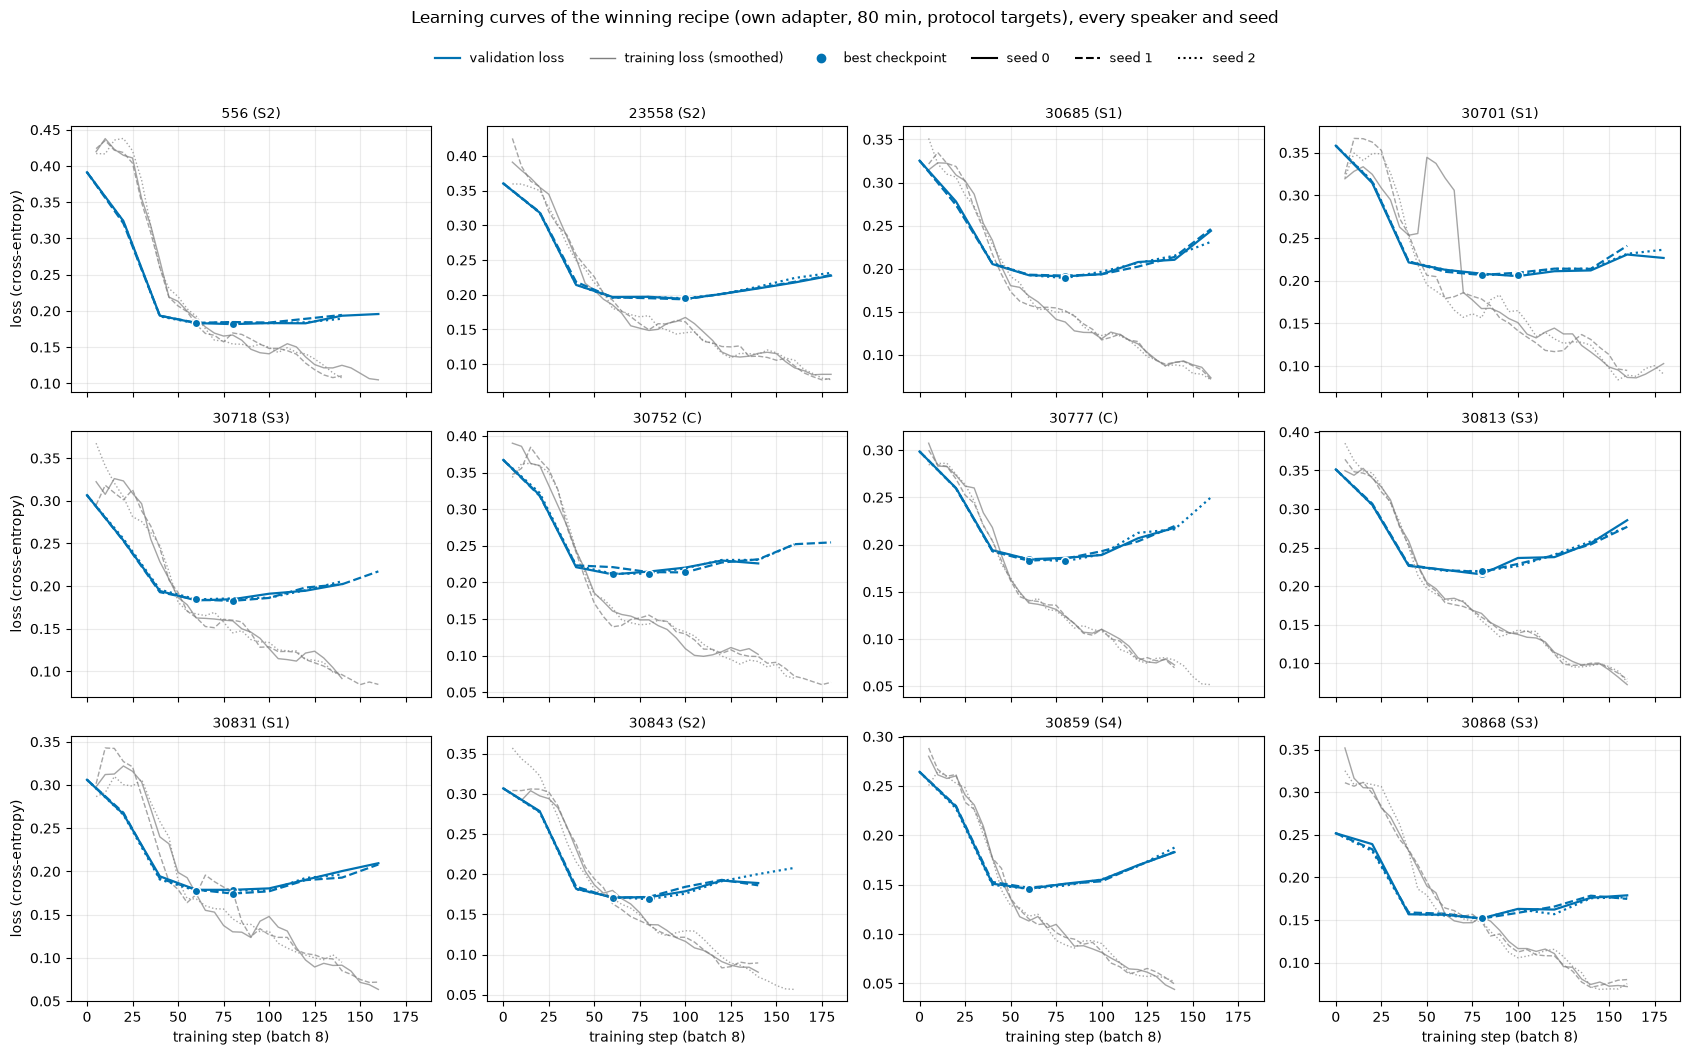

,best step,stopped at,untuned val loss,best val loss,val loss drop %
speaker,,,,,
556,66.667,146.667,0.391,0.183,53.309
23558,100.000,180.000,0.360,0.194,46.125
30685,80.000,160.000,0.325,0.191,41.403
30701,93.333,173.333,0.358,0.206,42.446
30718,66.667,146.667,0.307,0.183,40.183
30752,80.000,160.000,0.367,0.212,42.227
30777,66.667,146.667,0.299,0.183,38.636
30813,80.000,160.000,0.351,0.218,38.042
30831,73.333,153.333,0.306,0.177,42.197


,best step,stopped at,val loss drop %
count,36.0,36.0,36.0
mean,76.1,156.1,42.8
std,14.2,14.2,4.0
min,60.0,140.0,37.6
25%,60.0,140.0,39.8
50%,80.0,160.0,42.1
75%,80.0,160.0,44.6
max,100.0,180.0,53.6


In [10]:
fig, axes = plt.subplots(3, 4, figsize=(17, 10), sharex=True)
stats = []
for ax, spk in zip(axes.flat, SPK):
    for s in [0, 1, 2]:
        r = WIN[(WIN.speaker == spk) & (WIN.seed == s)].iloc[0]
        m = meta('runs', r.cell)
        tl = pd.DataFrame(m['train_log']).dropna(subset=['loss']).set_index('step').loss.rolling(4, min_periods=1).mean()
        ax.plot(tl.index, tl.values, color=C_BASE, ls=SEED_LS[s], lw=1, alpha=.7)
        ev = curve(m) * m['base_eval_loss']
        ax.plot(ev.index, ev.values, color=C_OWN, ls=SEED_LS[s], lw=1.6)
        ax.plot(m['best_step'], ev[m['best_step']], 'o', color=C_OWN, ms=6, mec='white')
        stats.append({'speaker': spk, 'seed': s, 'train chunks': m['train_chunks'], 'dev chunks': m['dev_chunks'],
                      'best step': m['best_step'], 'stopped at': m['global_step'], 'stopped early': m['stopped_early'],
                      'untuned val loss': m['base_eval_loss'], 'best val loss': m['best_eval_loss'],
                      'val loss drop %': 100 * (1 - m['best_eval_loss'] / m['base_eval_loss'])})
    ax.set_title(f'{spk} ({PROFILE[spk]})', fontsize=10); ax.grid(alpha=.25)
for ax in axes[:, 0]: ax.set_ylabel('loss (cross-entropy)')
for ax in axes[-1]: ax.set_xlabel('training step (batch 8)')
handles = [Line2D([], [], color=C_OWN, lw=1.6, label='validation loss'), Line2D([], [], color=C_BASE, lw=1, label='training loss (smoothed)'),
           Line2D([], [], marker='o', ls='', color=C_OWN, label='best checkpoint')]
handles += [Line2D([], [], color='k', ls=SEED_LS[s], label=f'seed {s}') for s in [0, 1, 2]]
fig.legend(handles=handles, loc='upper center', ncol=6, fontsize=9, frameon=False, bbox_to_anchor=(.5, 1.02))
fig.suptitle('Learning curves of the winning recipe (own adapter, 80 min, protocol targets), every speaker and seed', y=1.05)
plt.tight_layout(); save('winning_learning_curves'); plt.show()
S = pd.DataFrame(stats)
display(S.groupby('speaker')[['best step', 'stopped at', 'untuned val loss', 'best val loss', 'val loss drop %']].mean().round(3))
S[['best step', 'stopped at', 'val loss drop %']].describe().round(1)

**Reading.**
- **The curves are uniform across speakers and seeds.** Validation loss falls 38–54 % (median 42 %), bottoms
  out at step 60–100 (median 80, about 1.5–2 passes over the 80 minutes), and then rises while the training
  loss keeps falling.
- **Every run ended by early stopping, at step 140–180**, far below the 400-step cap.
- **The three seeds are almost indistinguishable in validation loss.** The seed-to-seed spread in test
  personalization (§2) does not show up in the loss.
- **The validation drop is only a rough guide to the test gain.** 556 and 23558 have the largest drops (53 % and
  46 %) and among the largest test gains, but 30701 gains as much on test with an average drop (42 %).

---
## 7. Numbers for the paper

The figures above carry the findings. These are the remaining numbers the paper's setup and results cite, so
that every number in the text has a cell it comes from.

### 7a. Data per speaker

In [11]:
w0 = WIN[WIN.seed == 0].set_index('speaker')
D = pd.DataFrame({
    'train min (80)': w0.train_minutes, 'train clips (80)': w0.train_chunks,
    'dev clips': [meta('runs', c)['dev_chunks'] for c in w0.cell],
    'clean test min': w0.test_minutes, 'clean test clips': w0.n_test, 'clean test words': w0.n_words,
    'full test min': w0['test07.test_minutes'], 'full test clips': w0['test07.n_test'],
    'clean share of full test': w0['test07.hq_share']})
for b in (5, 20):
    D[f'train clips ({b})'] = own[(own.budget == b) & (own.seed == 0)].set_index('speaker').train_chunks
D.index = [f'{s} ({PROFILE[s]})' for s in D.index]
display(D.round(2))
pd.DataFrame({'median': D.median(), 'min': D.min(), 'max': D.max(), 'total': D.sum()}).round(2)

,train min (80),train clips (80),dev clips,clean test min,clean test clips,clean test words,full test min,full test clips,clean share of full test,train clips (5),train clips (20)
23558 (S2),79.69,388,80,46.33,240,6154,177.78,1163,0.26,26,96
30685 (S1),79.97,285,66,45.85,155,5568,80.88,373,0.57,12,67
30701 (S1),79.82,361,77,47.47,183,6159,126.95,724,0.37,16,79
30718 (S3),79.95,344,76,55.58,162,7389,83.24,296,0.67,14,67
30752 (C),79.97,363,46,45.72,152,3933,72.18,320,0.63,29,87
30777 (C),79.94,266,48,49.04,156,6400,85.06,359,0.58,14,64
30813 (S3),79.77,296,58,57.18,208,6271,98.55,441,0.58,23,77
30831 (S1),79.74,266,50,50.10,173,5916,92.44,415,0.54,26,66
30843 (S2),79.85,272,40,30.23,112,3216,90.58,448,0.33,11,62
30859 (S4),79.90,251,70,47.56,166,5403,79.16,391,0.60,12,61


,median,min,max,total
train min (80),79.88,79.67,79.97,958.23
train clips (80),306.00,251.00,450.00,3858.00
dev clips,68.00,40.00,118.00,802.00
clean test min,47.29,30.23,57.18,567.20
clean test clips,164.00,112.00,240.00,2073.00
clean test words,6035.00,3216.00,7389.00,67813.00
full test min,89.89,72.18,177.78,1220.39
full test clips,423.00,296.00,1163.00,6158.00
clean share of full test,0.55,0.26,0.67,5.98
train clips (5),18.00,11.00,29.00,226.00


### 7b. The recipe and the training settings

The recipe the tuning rule chose (`recipe_v3.json`), plus the settings every final adapter recorded in its
`train_meta.json`. The check below confirms that all 60 protocol adapters share them.

In [12]:
keys = ['model', 'method', 'site', 'rank', 'lora_alpha', 'lora_dropout', 'batch', 'grad_accum', 'weight_decay', 'schedule', 'warmup_steps']
M = {c: meta('runs', c) for c in own.cell}
S7 = pd.DataFrame([{**{k: m['settings'][k] for k in keys + ['lr', 'budget']},
                    **{k: m[k] for k in ['max_steps', 'eval_steps', 'patience', 'dropout', 'augment', 'select', 'trainable_params', 'base_dtype']}}
                   for m in M.values()])
shared = {k: S7[k].iloc[0] for k in S7 if S7[k].nunique() == 1}
print('identical in all', len(S7), 'adapters:'); display(pd.Series(shared, dtype=object).to_frame('value'))
print('learning rate by budget:', S7.groupby('budget').lr.unique().to_dict())
pd.DataFrame(RECIPE).T

identical in all 60 adapters:


,value
model,ivrit-ai/whisper-large-v3
method,lora
site,both
rank,8
lora_alpha,16
lora_dropout,0.05
batch,8
grad_accum,1
weight_decay,0.01
schedule,constant_with_warmup


learning rate by budget: {5: array([0.0001]), 20: array([0.0003]), 80: array([0.0003])}


,lr,rank,dropout,augment
5,0.0001,8,0.0,none
20,0.0003,8,0.0,none
80,0.0003,8,0.0,none


### 7c. Error mix and runaway transcriptions

The share of word errors that are substitutions, deletions and insertions (`*.S/D/I`, which sum to 1), as a median
over speakers. Runaways are transcriptions more than 3× longer than the reference (a looping decoder), summed over
the 12 speakers. The base model's count is the same in every seed.

In [13]:
def mix(d, pre, who):
    return {e: 100 * d[f'{pre}{who}.{e}'].median() for e in 'SDI'}
rows = []
for pre, name in TESTS.items():
    t = name.split(' (')[0]
    rows.append({'test': t, 'model': 'base', **mix(WIN[WIN.seed == 0], pre, 'base')})
    rows.append({'test': t, 'model': 'own 80 min (36)', **mix(WIN, pre, 'tuned')})
    c80 = ctrl[ctrl.budget == 80]
    rows.append({'test': t, 'model': 'control 80 min (36)', **mix(c80, pre, 'tuned')})
display(pd.DataFrame(rows).round(1).rename(columns={'S': 'sub. %', 'D': 'del. %', 'I': 'ins. %'}))

rw = []
for pre, name in TESTS.items():
    t = name.split(' (')[0]
    rw.append({'test': t, 'base': int(WIN[WIN.seed == 0][pre + 'base.runaway'].sum()),
               **{f'own 80, seed {s}': int(WIN[WIN.seed == s][pre + 'tuned.runaway'].sum()) for s in (0, 1, 2)},
               **{f'control 80, seed {s}': int(ctrl[(ctrl.budget == 80) & (ctrl.seed == s)][pre + 'tuned.runaway'].sum()) for s in (0, 1, 2)}})
pd.DataFrame(rw).set_index('test')

,test,model,sub. %,del. %,ins. %
0,clean test,base,42.1,9.3,47.2
1,clean test,own 80 min (36),47.0,21.2,32.4
2,clean test,control 80 min (36),46.8,20.7,32.8
3,full test,base,33.6,12.9,51.9
4,full test,own 80 min (36),40.3,23.2,35.4
5,full test,control 80 min (36),39.4,22.0,36.4


,base,"own 80, seed 0","own 80, seed 1","own 80, seed 2","control 80, seed 0","control 80, seed 1","control 80, seed 2"
test,,,,,,,
clean test,3,1,1,1,2,1,2
full test,44,15,17,14,24,22,21


### 7d. How much a speaker's personalization moves between seeds

The SD over the 3 seeds of each speaker's personalization at 80 minutes, in relative points.

In [14]:
sd = pd.DataFrame({name.split(' (')[0]: 100 * WIN.groupby('speaker')[pre + 'personalization_rel'].std() for pre, name in TESTS.items()})
display(sd.round(1).T)
print('median per-speaker SD over seeds:', sd.median().round(1).to_dict(), '| mean:', sd.mean().round(1).to_dict())
pooled = {name.split(' (')[0]: round(100 * WIN[pre + 'personalization_rel'].median(), 1) for pre, name in TESTS.items()}
print('median personalization over all 36 speaker-seeds:', pooled)

speaker,556,23558,30685,30701,30718,30752,30777,30813,30831,30843,30859,30868
clean test,1.6,2.4,1.0,2.6,3.5,3.3,2.5,0.6,2.8,2.4,1.3,3.7
full test,1.7,0.4,0.5,1.6,1.3,0.7,1.7,1.4,1.1,1.0,1.1,0.1


median per-speaker SD over seeds: {'clean test': 2.4, 'full test': 1.1} | mean: {'clean test': 2.3, 'full test': 1.0}
median personalization over all 36 speaker-seeds: {'clean test': np.float64(2.4), 'full test': np.float64(2.2)}


### 7e. Cost per adapter

In [15]:
C7 = own.groupby('budget').agg(**{'train s (median)': ('seconds_train', 'median'), 'total s incl. both tests (median)': ('seconds_total', 'median'),
                                  'steps (median)': ('train_steps', 'median')})
C7['peak GPU GB (median)'] = [np.median([M[c]['peak_gpu_mem_gb'] for c in own[own.budget == b].cell]) for b in C7.index]
C7['best step (median)'] = [np.median([M[c]['best_step'] for c in own[own.budget == b].cell]) for b in C7.index]
print('trainable parameters per adapter:', f"{S7.trainable_params.iloc[0]:,}")
C7.round(1)

trainable parameters per adapter: 3,932,160


,train s (median),total s incl. both tests (median),steps (median),peak GPU GB (median),best step (median)
budget,,,,,
5,105.0,251.0,150.0,23.1,70.0
20,85.2,129.4,120.0,23.6,40.0
80,110.7,157.3,160.0,23.7,80.0
